# 00 验证一下

In [ ]:
from scipy.stats import uniform
from scipy.stats import randint
from scipy.stats import loguniform

rvs = uniform.rvs(loc=0.545, scale=0.413, size=10000)
print(rvs.min(), rvs.max())
rvs = randint.rvs(5, 14, size=10000)
print(rvs.min(), rvs.max())
rvs = loguniform.rvs(0.002, 0.355, size=10000)
print(rvs.min(), rvs.max())

# 01 首先specify hyperparameters, 根据paper里面对于xgboost的调参参考，得到了GBDT的几个参数建议
《Comparing hyperparameter tuning methods in machine learning based urban building energy modeling: A study in Chicago - ScienceDirect》

# 01 GBDT training -> 这个在 3_480m_based 中已经实现了

# 忘记是干嘛的了 关于 prediction 和PDP的出图，在文件 GBDT_tailored.ipynb 中。

In [ ]:
# # 这个代码会读取你之前保存的 训练集 vs 测试集 R² 指标表格，然后把不同网格大小下的 Train/Test R² 曲线画出来。最后，它会为每个目标变量（nor/ext/hr）分别保存一张对比图到指定文件夹。

# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# # === 文件路径 ===
# grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
# for year in [2016,2023]:
#     input_path = os.path.join(grid_folder, f'{year} R2_Comparison_Train_vs_Test.xlsx')
#     output_dir = os.path.join(grid_folder, 'figures', 'r2_comparison')
#     os.makedirs(output_dir, exist_ok=True)

#     # === 读取数据 ===
#     df = pd.read_excel(input_path)
#     df['GridSize'] = df['GridSize'].astype(int)

#     # === 绘图：每个 Target 一个对比图 ===
#     for target in df['Target'].unique():
#         df_sub = df[df['Target'] == target].sort_values('GridSize')

#         plt.figure(figsize=(8, 5))
#         plt.plot(df_sub['GridSize'], df_sub['Train_R2'], marker='o', label='Train R²')
#         plt.plot(df_sub['GridSize'], df_sub['Test_R2'], marker='o', label='Test R²')

#         plt.title(f'R² Comparison — {target}')
#         plt.xticks(sorted(df['GridSize'].unique()))  # ✅ 强制显示真实 X 值
#         plt.xlabel('Grid Size (m)')
#         plt.ylabel('R² Score')
#         plt.ylim(0, 1.05)
#         plt.grid(True)
#         plt.legend()
#         plt.tight_layout()

#         out_path = os.path.join(output_dir, f'{year} R2_Train_vs_Test_{target}.png')
#         plt.savefig(out_path, dpi=300)
#         plt.close()
#         print(f"📈 Saved R² comparison: {out_path}")

# 02 CV result

In [ ]:
import os
import pandas as pd
work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
folder = os.path.join(work_folder, r'16_6387_GBDT_hr_2016_cv_results.xlsx')
file = pd.read_excel(folder)
file

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,param_subsample,...,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score,mean_test_score,std_test_score,rank_test_score
0,75.811172,63.756662,0.107415,0.119423,0.034310,10,0.825518,2,4168,0.899332,...,0.901533,0.890866,0.911724,0.896975,0.903246,0.893036,0.866596,0.893874,0.014852,153
1,13.059228,14.271990,0.020635,0.033087,0.160941,8,0.710264,2,4168,0.725724,...,0.901439,0.886276,0.908546,0.886311,0.885778,0.897446,0.868310,0.891677,0.015263,164
2,8.121032,8.910455,0.034728,0.065140,0.202677,13,0.493413,2,4168,0.742276,...,0.875051,0.887577,0.894577,0.893222,0.871674,0.892271,0.839738,0.878045,0.016784,188
3,9.428400,10.155298,0.025746,0.049743,0.134202,13,0.563208,2,4168,0.890301,...,0.889637,0.889041,0.906039,0.890239,0.896779,0.892963,0.864942,0.886148,0.016252,173
4,37.142518,37.338834,0.174345,0.195607,0.011479,9,0.346747,2,4168,0.888872,...,0.903451,0.907251,0.917078,0.902709,0.905254,0.902936,0.874696,0.899568,0.014354,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,11.792527,13.109565,0.018610,0.032408,0.314812,5,0.896473,2,4168,0.754653,...,0.881850,0.888031,0.907063,0.886752,0.898942,0.878337,0.849989,0.883506,0.016445,179
196,33.621891,34.071841,0.103519,0.125653,0.009478,7,0.576278,2,4168,0.716646,...,0.911907,0.909809,0.923447,0.908473,0.916359,0.910985,0.883369,0.907486,0.014018,30
197,7.366595,8.030015,0.017817,0.037059,0.255663,12,0.844769,2,4168,0.698602,...,0.877384,0.866662,0.885987,0.882241,0.887809,0.883236,0.837030,0.876038,0.017204,191
198,34.921532,31.918235,0.097310,0.115142,0.002014,7,0.519894,2,4168,0.899675,...,0.905654,0.906962,0.919558,0.905333,0.908840,0.906952,0.878867,0.903556,0.014307,63


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import Counter

work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
name = r"GBDT_hr_2016_cv_results.xlsx"
results = []  # 存储所有文件的结果

# 遍历文件夹找目标文件
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)

        # 读入
        df = pd.read_excel(folder)

        # 找最大值对应的行
        best_row = df.loc[df['mean_test_score'].idxmax()]

        prefix = file.split("_GBDT")[0]  # 截取前缀，比如 "15_3184"
        seed_num = int(prefix.split("_")[0])  # 提取前缀里的第一个数字部分

        # 把结果存入列表
        results.append({
            "Seed": seed_num,
            "文件前缀": prefix,
            "最优分数": best_row['mean_test_score'],
            "learning_rate": float(best_row['param_learning_rate']),
            "subsample": float(best_row['param_subsample']),
            "max_depth": int(best_row['param_max_depth']),
            "max_features": float(best_row['param_max_features'])
        })

# 转成 DataFrame
results_df = pd.DataFrame(results)

# 按 Seed 排序
results_df = results_df.sort_values(by="Seed").reset_index(drop=True)

# print("==== 所有结果表格 ====")
print(results_df)

# 每个参数的唯一值统计
print("\n==== 每个参数的唯一值统计 ====")
for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
    counts = results_df[col].value_counts()
    print(f"\n参数 {col}:")
    print(counts)

print("\n==== 每个参数的最高频取值 ====")
top_values = {}
for col in ["learning_rate", "subsample", "max_depth", "max_features"]:
    counts = results_df[col].value_counts()
    top_val = counts.idxmax()   # 出现次数最多的取值
    top_count = counts.max()    # 出现次数
    print(f"参数 {col}: 最常见值 = {top_val}, 出现次数 = {top_count}")
    top_values[col] = (top_val, top_count)
print(top_values)

# 先把最高频参数提取出来
best_params = {
    "param_learning_rate": top_values["learning_rate"][0],
    "param_subsample": top_values["subsample"][0],
    "param_max_depth": top_values["max_depth"][0],
    "param_max_features": top_values["max_features"][0],
}

print("\n==== 使用最高频参数组合查找对应的CV结果 ====")
print(best_params)
scores = []  # 保存 (文件前缀, 分数)

for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)

        # 筛选符合最高频参数组合的行
        mask = (
            (df["param_learning_rate"] == best_params["param_learning_rate"]) &
            (df["param_subsample"] == best_params["param_subsample"]) &
            (df["param_max_depth"] == best_params["param_max_depth"]) &
            (df["param_max_features"] == best_params["param_max_features"])
        )
        match = df.loc[mask]

        if not match.empty:
            mean_score = match["mean_test_score"].values[0]
            prefix = file.split("_GBDT")[0]
            scores.append((prefix, mean_score))
            print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# 计算平均值
if scores:
    all_scores = [s[1] for s in scores]
    avg_score = sum(all_scores) / len(all_scores)
    print(f"\n平均 mean_test_score = {avg_score}")

    # 找最接近平均值的那个
    closest = min(scores, key=lambda x: abs(x[1] - avg_score))
    print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed     文件前缀      最优分数  learning_rate  subsample  max_depth  max_features
0      0   0_9394  0.914752       0.011021   0.565109          5      0.836007
1      1    1_898  0.914906       0.011021   0.565109          5      0.836007
2      2   2_2398  0.918615       0.013651   0.563425          5      0.602176
3      3   3_5906  0.918484       0.019596   0.557018          5      0.711836
4      4   4_2343  0.916721       0.013651   0.563425          5      0.602176
5      5   5_8225  0.912296       0.011021   0.565109          5      0.836007
6      6   6_5506  0.917759       0.013651   0.563425          5      0.602176
7      7   7_6451  0.915307       0.013651   0.563425          5      0.602176
8      8   8_2670  0.915465       0.011021   0.565109          5      0.836007
9      9   9_3497  0.916365       0.011021   0.565109          5      0.836007
10    10  10_1087  0.917739       0.011021   0.565109          5      0.836007
11    11  11_1819  0.915541       0.013651   0.56342

# 1

In [8]:
import os
import pandas as pd

work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
name = r"GBDT_hr_2016_cv_results.xlsx"
results = []  

# 遍历文件夹找目标文件
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        best_row = df.loc[df['mean_test_score'].idxmax()]
        prefix = file.split("_GBDT")[0]
        seed_num = int(prefix.split("_")[0])  

        results.append({
            "Seed": seed_num,
            "prefix": prefix,
            "mean_test_score": best_row['mean_test_score'],
            "learning_rate": float(best_row['param_learning_rate']),
            "subsample": float(best_row['param_subsample']),
            "max_depth": int(best_row['param_max_depth']),
            "max_features": float(best_row['param_max_features'],)
        })

# 转成 DataFrame
results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)
print(results_df)
results_df.to_excel(os.path.join(work_folder, 'cv_pairs.xlsx'), index=False)

# === 统计完整组合出现次数 ===
combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
    .value_counts().reset_index(name="count")
print(combo_counts)

# 取出现次数最多的组合
best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
print("\n==== 出现最多的参数组合 ====")
print(best_combo)

# === 用这个组合查找对应的 mean_test_score ===
scores = []
for file in os.listdir(work_folder):
    if file.endswith(name):
        folder = os.path.join(work_folder, file)
        df = pd.read_excel(folder)
        mask = (
            (df["param_learning_rate"] == best_combo["learning_rate"]) &
            (df["param_subsample"] == best_combo["subsample"]) &
            (df["param_max_depth"] == best_combo["max_depth"]) &
            (df["param_max_features"] == best_combo["max_features"])
        )
        match = df.loc[mask]
        if not match.empty:
            mean_score = match["mean_test_score"].values[0]
            prefix = file.split("_GBDT")[0]
            scores.append((prefix, mean_score))
            print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

# 平均值 + 最接近的结果
if scores:
    all_scores = [s[1] for s in scores]
    avg_score = sum(all_scores) / len(all_scores)
    print(f"\n平均 mean_test_score = {avg_score}")
    closest = min(scores, key=lambda x: abs(x[1] - avg_score))
    print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")


    Seed   prefix  mean_test_score  learning_rate  subsample  max_depth  \
0      0   0_9394         0.914752       0.011021   0.565109          5   
1      1    1_898         0.914906       0.011021   0.565109          5   
2      2   2_2398         0.918615       0.013651   0.563425          5   
3      3   3_5906         0.918484       0.019596   0.557018          5   
4      4   4_2343         0.916721       0.013651   0.563425          5   
5      5   5_8225         0.912296       0.011021   0.565109          5   
6      6   6_5506         0.917759       0.013651   0.563425          5   
7      7   7_6451         0.915307       0.013651   0.563425          5   
8      8   8_2670         0.915465       0.011021   0.565109          5   
9      9   9_3497         0.916365       0.011021   0.565109          5   
10    10  10_1087         0.917739       0.011021   0.565109          5   
11    11  11_1819         0.915541       0.013651   0.563425          5   
12    12  12_2308        

# 2

In [159]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial
import os
import pandas as pd



grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
target = 'hr_2016'
print(best_combo)
# 已经固定的最佳参数
best_params = {
    'learning_rate':  best_combo["learning_rate"],
    'max_depth': int(best_combo["max_depth"]),
    'n_estimators': 4168,
    'subsample': best_combo["subsample"],
    'min_samples_split': 2,
    'max_features': best_combo["max_features"],
}
print({k: type(v) for k, v in best_params.items()})

np.random.seed(0)  # 固定种子以便复现
random_seeds = np.random.choice(10000, size=20, replace=False)

years = [2016]
for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

X = gdf_clean[explanatory_vars_gbdt]
y = gdf_clean[target]
# 假设你已有 X, y（特征和目标），只是要划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seeds[9]
)
print(random_seeds[9])
# 定义并训练模型
model = GradientBoostingRegressor(**best_params, random_state=0)
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算指标
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

# 打印结果
print("==== Final Model Performance ====")
print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
# 特征重要性
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": explanatory_vars_gbdt,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n==== Feature Importances ====")
print(feature_importance)

# # 可视化
# plt.figure(figsize=(8, 5))
# plt.barh(feature_importance["Feature"], feature_importance["Importance"])
# plt.gca().invert_yaxis()  # 让最重要的排在最上面
# plt.xlabel("Importance")
# plt.title("Feature Importances (GBDT)")
# plt.tight_layout()
# plt.show()

{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
{'learning_rate': <class 'float'>, 'max_depth': <class 'int'>, 'n_estimators': <class 'int'>, 'subsample': <class 'float'>, 'min_samples_split': <class 'int'>, 'max_features': <class 'float'>}
3497
==== Final Model Performance ====
Train R²: 0.9994, RMSE: 0.0422
Test  R²: 0.9253, RMSE: 0.4928

==== Feature Importances ====
   Feature  Importance
0      BCR    0.447111
3     NDVI    0.152739
10       Y    0.090826
1      BHV    0.079528
5       WR    0.063781
9        X    0.041905
6   Dist_W    0.030974
4       EV    0.029060
2      SVF    0.027650
8   Dist_M    0.019639
7   Dist_P    0.016787


c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# 1 + 2 predict models 

In [161]:
# 简化后的找参数 01
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from libpysal.weights import DistanceBand, lag_spatial

all_results = []  # 存所有结果

target_ranges = ['nor_2016','ext_2016','hr_2016']
for target in target_ranges:

    work_folder = r'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning'
    name = rf"GBDT_{target}_cv_results.xlsx"
    results = []  

    # 遍历文件夹找目标文件
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])  

            results.append({
                "Seed": seed_num,
                "文件前缀": prefix,
                "最优分数": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    # 转成 DataFrame
    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # === 统计完整组合出现次数 ===
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print(combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("\n==== 出现最多的参数组合 ====")
    print(best_combo)

    # === 用这个组合查找对应的 mean_test_score ===
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(name):
            folder = os.path.join(work_folder, file)
            df = pd.read_excel(folder)
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))
                print(f"文件前缀：{prefix}, mean_test_score = {mean_score}")

    # 平均值 + 最接近的结果
    if scores:
        all_scores = [s[1] for s in scores]
        avg_score = sum(all_scores) / len(all_scores)
        print(f"\n平均 mean_test_score = {avg_score}")
        closest = min(scores, key=lambda x: abs(x[1] - avg_score))
        print(f"最接近平均值的文件前缀：{closest[0]}, mean_test_score = {closest[1]}")
        seed_idx, seed_value = closest[0].split("_")
        seed_idx = int(seed_idx)
        print(f"最接近平均值的文件前缀：{closest[0]} "
            f"(第 {seed_idx} 个 random seed, 值={seed_value}), "
            f"mean_test_score = {closest[1]}")

    ######################################################################
    grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
    explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究

    print(best_combo)
    # 已经固定的最佳参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }
    # print({k: type(v) for k, v in best_params.items()})

    np.random.seed(0)  # 固定种子以便复现
    random_seeds = np.random.choice(10000, size=20, replace=False)

    years = [2016]
    for year in years:
        # 清理后的网格数据
        file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]
    # 假设你已有 X, y（特征和目标），只是要划分
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seeds[seed_idx]
    )
    print(random_seeds[9])
    # 定义并训练模型
    model = GradientBoostingRegressor(**best_params, random_state=0)
    model.fit(X_train, y_train)

    # 预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 计算指标
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
    test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

    # 打印结果
    print("==== Final Model Performance ====")
    print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    # 特征重要性
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n==== Feature Importances ====")
    print(feature_importance)

    # # 可视化
    # plt.figure(figsize=(8, 5))
    # plt.barh(feature_importance["Feature"], feature_importance["Importance"])
    # plt.gca().invert_yaxis()  # 让最重要的排在最上面
    # plt.xlabel("Importance")
    # plt.title(f"{target} Feature Importances (GBDT)")
    # plt.tight_layout()
    # plt.show()

    ###########################################################################

    # Feature importance 
    importances = model.feature_importances_
    feature_importance = pd.DataFrame({
        "Feature": explanatory_vars_gbdt,
        "FeatureImportance_TrainModel": importances
    })

    # 拼接额外信息
    feature_importance["GridSize"] = 480
    feature_importance["Target"] = target
    feature_importance["Random seed"] = random_seeds[seed_idx]
    feature_importance["Train_R2"] = train_r2
    feature_importance["Train_RMSE"] = train_rmse
    feature_importance["Test_R2"] = test_r2
    feature_importance["Test_RMSE"] = test_rmse
    feature_importance["learning_rate"] = best_params["learning_rate"]
    feature_importance["max_depth"] = best_params["max_depth"]
    feature_importance["max_features"] = best_params["max_features"]
    feature_importance["min_samples_split"] = best_params["min_samples_split"]
    feature_importance["n_estimators"] = best_params["n_estimators"]
    feature_importance["subsample"] = best_params["subsample"]
    feature_importance["CV_mean_test_score "] = avg_score

    # 存入总列表
    all_results.append(feature_importance)

# 合并所有 target 的结果
final_df = pd.concat(all_results, ignore_index=True)

# 打印预览
print(final_df.head())

# 保存到 Excel
final_df.to_excel(r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx", index=False)

   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176     20

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9206258884211889
文件前缀：10_1087, mean_test_score = 0.9207890630433994
文件前缀：11_1819, mean_test_score = 0.9189680765029862
文件前缀：12_2308, mean_test_score = 0.9265491231731785
文件前缀：13_6084, mean_test_score = 0.9162900161040518
文件前缀：14_3724, mean_test_score = 0.9180319870973522
文件前缀：15_3184, mean_test_score = 0.9200275643594082
文件前缀：16_6387, mean_test_score = 0.9180880798678325
文件前缀：17_3728, mean_test_score = 0.9199742707159965
文件前缀：18_2702, mean_test_score = 0.9209419174504384
文件前缀：19_7883, mean_test_score = 0.921920552334514
文件前缀：1_898, mean_test_score = 0.9209281882715543
文件前缀：2_2398, mean_test_score = 0.9200878924842101
文件前缀：3_5906, mean_test_score = 0.9180863643324828
文件前缀：4_2343, mean_test_sco

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9997, RMSE: 0.0439
Test  R²: 0.9237, RMSE: 0.6969

==== Feature Importances ====
   Feature  Importance
0      BCR    0.262765
3     NDVI    0.252275
5       WR    0.127736
4       EV    0.102801
2      SVF    0.057759
1      BHV    0.045498
9        X    0.035770
8   Dist_M    0.034620
6   Dist_W    0.031706
10       Y    0.026400
7   Dist_P    0.022670
   learning_rate  subsample  max_depth  max_features  count
0       0.013651   0.563425          5      0.602176     20

==== 出现最多的参数组合 ====
{'learning_rate': 0.0136505925090242, 'subsample': 0.5634248804179491, 'max_depth': 5.0, 'max_features': 0.6021762684622403}
文件前缀：0_9394, mean_test_score = 0.9486139473126189
文件前缀：10_1087, mean_test_score = 0.9490290521412226
文件前缀：11_1819, mean_test_score = 0.9473135961269996
文件前缀：12_2308, mean_test_score = 0.9527174169979921
文件前缀：13_6084, mean_test_score = 0.9464109697739229
文件前缀：14_3724, mean_test_score = 0.9472953860992247
文件前缀：15_3184, mean_test_sc

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


==== Final Model Performance ====
Train R²: 0.9998, RMSE: 0.0563
Test  R²: 0.9538, RMSE: 0.8294

==== Feature Importances ====
   Feature  Importance
0      BCR    0.339154
3     NDVI    0.201131
1      BHV    0.133441
5       WR    0.100933
4       EV    0.074634
2      SVF    0.041990
6   Dist_W    0.035836
10       Y    0.025307
8   Dist_M    0.018709
9        X    0.017587
7   Dist_P    0.011277
   learning_rate  subsample  max_depth  max_features  count
0       0.011021   0.565109          5      0.836007     11
1       0.013651   0.563425          5      0.602176      8
2       0.019596   0.557018          5      0.711836      1

==== 出现最多的参数组合 ====
{'learning_rate': 0.01102140393287835, 'subsample': 0.5651090922378933, 'max_depth': 5.0, 'max_features': 0.8360070757116593}
文件前缀：0_9394, mean_test_score = 0.9147522903014067
文件前缀：10_1087, mean_test_score = 0.9177390863334338
文件前缀：11_1819, mean_test_score = 0.9151008911254996
文件前缀：12_2308, mean_test_score = 0.9191270028293715
文件前缀：13

c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\owner\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# feature importance 出图

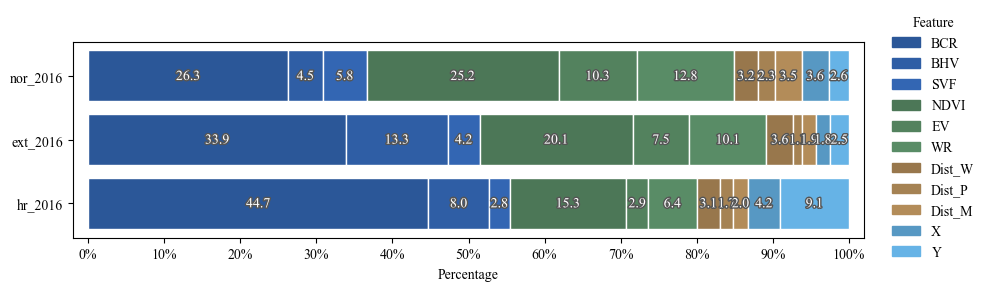

Saved to: D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_summary_results.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)

# 归一化（每个 target 的行和为 1）
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# 手动调整 Target 的行顺序
row_order = ['hr_2016', 'ext_2016','nor_2016']
pivot_norm = pivot_norm.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot_norm))))
bottom = np.zeros(len(pivot_norm))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot_norm[feature].values
    ax.barh(pivot_norm.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")
# ax.set_ylabel("Target")
# ax.set_title("Feature importance proportions per Target")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\final_GBDT_feature_importance_stacked.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

# 出一下不同的seed的PDP 值

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# ----------------- 配置 -----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)


explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
years = [2016]
top_n_features = 9  # PDP 提取 top N 变量

# ----------------- 主循环 -----------------
for year in years:
    file = fr'D:\seoul\grids\lst_map\final_clean\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file)
    
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\cv_pairs.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    # --- 目标变量分组 ---
    targets = 'hr_2016'

    for feature in explanatory_vars:
        # 建一张图
        fig, ax = plt.subplots(figsize=(8,5))

        for seed in range(20):
            row_gbdt = best_df_gbdt[best_df_gbdt['Seed'] == seed].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': 4168,
                'subsample': row_gbdt['subsample'],
                'min_samples_split': 2,
                'max_features': float(row_gbdt['max_features']),
                'random_state': 0
            }

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[targets]   # 注意这里应该是 targets 而不是 target
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2,
                random_state=int(str(row_gbdt["prefix"]).split("_")[1])
            )
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            # ----------- PDP 计算部分 -----------

            X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
            X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
            X_base[feature] = X_grid

            y_gbdt_pred = model.predict(X_base)

            for x in X[feature]:
                plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
            if seed == 9:
                ax.plot(X_grid, y_gbdt_pred, linewidth=2.5, color="red", 
                        label="The final nonlinear curve", zorder=10)
            else:
                ax.plot(X_grid, y_gbdt_pred, linewidth=1, color="gray", alpha=0.5, zorder=1)


        # 设置全局字体为 Times New Roman
        plt.rcParams["font.family"] = "Times New Roman"
        plt.xlabel(feature, fontsize=16)
        plt.ylabel('Temperature (℃)', fontsize=16)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(False)
        ax.legend()
        ax.set_ylim(-20, 0)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'Seed_PDP_{feature}_hr.jpg'), dpi=300)
        plt.close(fig)


: 

# 出一下不同的seed的预测值

In [ ]:
# ==== 最终版：20 seeds 结果输出 ====
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ---------------- 配置 ----------------
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
work_folder = os.path.join(grid_folder, "Machine Learning")
cv_file = "cv_pairs.xlsx"   # 你的CV结果文件
output_file = os.path.join(work_folder, "final_GBDT_summary_results_20seeds.xlsx")

explanatory_vars_gbdt = ['BCR','BHV','SVF','NDVI','EV','WR','Dist_W','Dist_P','Dist_M','X','Y']
target_ranges = ['nor_2016','ext_2016','hr_2016']
years = [2016]

all_results = []  # 存所有结果

# ---------------- 主循环 ----------------
for target in target_ranges:
    print(f"\n==== Target: {target} ====")

    # 1) 收集CV结果（找最常见参数组合）
    results = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            best_row = df.loc[df['mean_test_score'].idxmax()]
            prefix = file.split("_GBDT")[0]
            seed_num = int(prefix.split("_")[0])

            results.append({
                "Seed": seed_num,
                "prefix": prefix,
                "mean_test_score": best_row['mean_test_score'],
                "learning_rate": float(best_row['param_learning_rate']),
                "subsample": float(best_row['param_subsample']),
                "max_depth": int(best_row['param_max_depth']),
                "max_features": float(best_row['param_max_features'])
            })

    results_df = pd.DataFrame(results).sort_values(by="Seed").reset_index(drop=True)

    # 统计完整组合出现次数
    combo_counts = results_df[["learning_rate","subsample","max_depth","max_features"]] \
        .value_counts().reset_index(name="count")
    print("参数组合频率：\n", combo_counts)

    # 取出现次数最多的组合
    best_combo = combo_counts.iloc[0][["learning_rate","subsample","max_depth","max_features"]].to_dict()
    print("最常见参数组合：", best_combo)

    # 用这个组合查找对应的 mean_test_score
    scores = []
    for file in os.listdir(work_folder):
        if file.endswith(cv_file):
            df = pd.read_excel(os.path.join(work_folder, file))
            mask = (
                (df["param_learning_rate"] == best_combo["learning_rate"]) &
                (df["param_subsample"] == best_combo["subsample"]) &
                (df["param_max_depth"] == best_combo["max_depth"]) &
                (df["param_max_features"] == best_combo["max_features"])
            )
            match = df.loc[mask]
            if not match.empty:
                mean_score = match["mean_test_score"].values[0]
                prefix = file.split("_GBDT")[0]
                scores.append((prefix, mean_score))

    avg_score = np.mean([s[1] for s in scores]) if scores else np.nan
    print(f"CV 平均 mean_test_score = {avg_score:.6f}")

    # 2) 固定参数
    best_params = {
        'learning_rate':  best_combo["learning_rate"],
        'max_depth': int(best_combo["max_depth"]),
        'n_estimators': 4168,
        'subsample': best_combo["subsample"],
        'min_samples_split': 2,
        'max_features': best_combo["max_features"],
    }

    # 3) 遍历 20 个随机种子
    np.random.seed(0)
    random_seeds = np.random.choice(10000, size=20, replace=False)

    for year in years:
        file = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
        gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    X = gdf_clean[explanatory_vars_gbdt]
    y = gdf_clean[target]

    for seed in random_seeds:
        # 划分训练测试
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

        # 训练模型
        model = GradientBoostingRegressor(**best_params, random_state=seed)
        model.fit(X_train, y_train)

        # 预测 & 指标
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
        test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

        # 特征重要性
        feature_importance = pd.DataFrame({
            "Feature": explanatory_vars_gbdt,
            "FeatureImportance_TrainModel": model.feature_importances_
        })

        # 拼接额外信息
        feature_importance["GridSize"] = 480
        feature_importance["Target"] = target
        feature_importance["Random seed"] = seed
        feature_importance["Train_R2"] = train_r2
        feature_importance["Train_RMSE"] = train_rmse
        feature_importance["Test_R2"] = test_r2
        feature_importance["Test_RMSE"] = test_rmse
        feature_importance["learning_rate"] = best_params["learning_rate"]
        feature_importance["max_depth"] = best_params["max_depth"]
        feature_importance["max_features"] = best_params["max_features"]
        feature_importance["min_samples_split"] = best_params["min_samples_split"]
        feature_importance["n_estimators"] = best_params["n_estimators"]
        feature_importance["subsample"] = best_params["subsample"]
        feature_importance["CV_mean_test_score"] = avg_score  # 这里存CV均值

        all_results.append(feature_importance)

# ---------------- 保存结果 ----------------
final_df = pd.concat(all_results, ignore_index=True)
print(final_df.head())

final_df.to_excel(output_file, index=False)
print(f"\n✅ 已保存到 {output_file}")


# >>>>>> final GBDT + SDM result

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import DistanceBand, lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]: 

    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 删除 NA
                data = gdf[explanatory_vars + [target]].dropna()
                data_gdf = gdf.loc[data.index]

                # 权重矩阵
                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values

                # SDM slx 变量
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]

                # --- 模型 ---
                model_sdm = ML_Lag(
                    yi, X_main, w=w,
                    slx_lags=1, slx_vars=slx_vars_bool,
                    name_y=target, name_x=explanatory_vars,
                    name_w=f"W{threshold}", name_ds=f"yr{year}",
                    spat_diag=True, spat_impacts=['full']
                )

                # --- 提取系数 ---
                formula_sdm = show_formula(model_sdm, model_type='SDM')
                coef_sdm = dict(zip(model_sdm.name_x, model_sdm.betas.flatten()))

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

# -----------------------------
# 输出
# -----------------------------
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_all_params_480m.xlsx")
all_params_df.to_excel(param_output, index=False)

print("保存完成")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

保存完成


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_all_params_480m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")